#### Chaimaa Faouzi
#### Master Génie Logiciel pour le Cloud Computing
#### Ce projet a pour objectif de réaliser trois types de régression (simple, multiple, polynominale) sur un dataset réel de prix de voitures. Je vais explorer les données, les nettoyer, puis appliquer des modèles de régression pour prédire le prix en fonction des caractéristiques des voitures.

### * Régression linéaire simple :

In [23]:
# 1. Import des bibliothèques

import pandas as pd    #pour manipuler et analyser les données tabulaires,et charger dataset
import numpy as np     #pout calculer gradient descent,et calcule les erreurs
import matplotlib.pyplot as plt    #pour crée des graphiques
import seaborn as sns              #pour visualisations plus avancées et jolies

from sklearn.model_selection import train_test_split    #pour séparer les données en training et testing
from sklearn.linear_model import LinearRegression       #pour crée un modèle de regression automatiquement
from sklearn.preprocessing import PolynomialFeatures    #pour transformer un variable en : x², x³…
from sklearn.preprocessing import StandardScaler        #pour standardiser les données pour que chaque variable
from sklearn.metrics import mean_squared_error, r2_score    #pour évaluer mon modèle
from mpl_toolkits.mplot3d import Axes3D   #pour créer des graphiques en 3D avec matplotlib.

import warnings     #pour masquer les messages d'erreur non importants
warnings.filterwarnings('ignore')

In [24]:
# 2. Chargement des données

data = pd.read_csv("TP_ML/car_price_prediction_.csv")

print(data.head())    #affiche les 5 premières lignes du dataset pour comprendre sa structure et visualiser les différentes colonnes.
print(data.info())    #permet d'obtenir le nombre de lignes, les types des variables(numérique ou catégorielle) et la présence de valeurs manquantes
print(data.isnull().sum())     #pour vérifie s’il existe des valeurs manquantes dans le dataset.

data.describe()   #permet de calculer le moyenne(mean), minimum(min), maximum(max) et l'écart-type(std) cela permet de comprendre la distribution des données 

   Car ID  Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0       1  Tesla  2016          2.3    Petrol       Manual   114832       New   
1       2    BMW  2018          4.4  Electric       Manual   143190      Used   
2       3   Audi  2013          4.5  Electric       Manual   181601       New   
3       4  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4       5   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4  

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


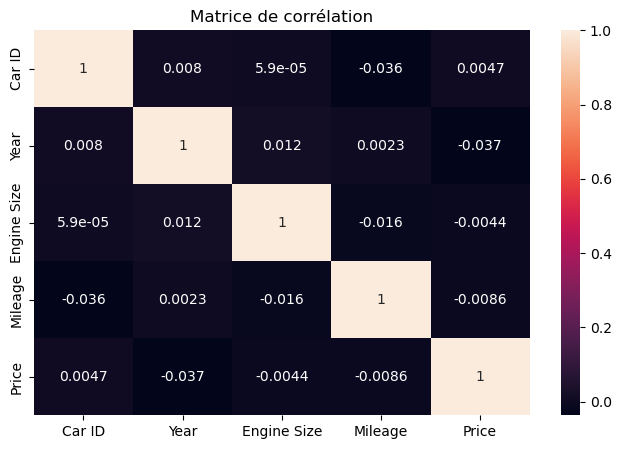

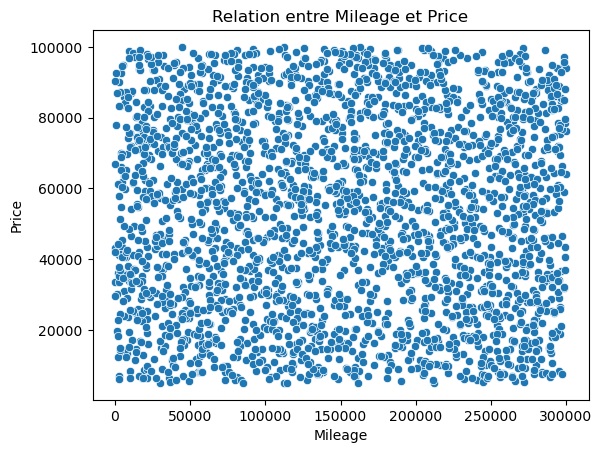

In [25]:
# 3. Visualisation

plt.figure(figsize=(8,5))   #Crée une nouvelle figure (fenêtre de graphique) de largeur 8 et hauteur 5
sns.heatmap(data.corr(numeric_only=True), annot=True)
#data.corr(numeric_only=True) :calcule la corrélation entre les variables numériques  
#annot=True   :affiche les valeurs numériques dans les cases 

plt.title("Matrice de corrélation")   #ajoute un titre au graphique
plt.show()   #affiche le graphique à l'écran

sns.scatterplot(x=data['Mileage'], y=data['Price'])   #crée un nuage de points. Chaque point représente une voiture dans le dataset
plt.title("Relation entre Mileage et Price")
plt.show()

In [26]:
# 4. Préparation des données

X_original = data['Mileage'].values.reshape(-1,1)   #On sélectionne la variable indépendante "Mileage" (kilométrage), reshape(-1,1) permet de transformer en vecteur colonne pour les calculs matriciels
y = data['Price'].values.reshape(-1,1)     #On récupère la variable dépendante dénpendante "Price" et transforme le vecteur en colonne (matrice)

X = (X_original - X_original.mean()) / X_original.std()    # On normalise X pour mettre toutes les variables sur la même échelle et améliorer la convergence de la descente de gradient

# Afin de simplifier les calculs matriciels, on ajoute une colonne de 1 à la matrice X
#Cela permet d’intégrer le biais (beta0) dans le vecteur des paramètres beta, et d’écrire le modèle sous forme matricielle : ŷ = Xβ
m = len(y)
X_b = np.hstack([np.ones((m,1)), X])

In [27]:
# 5. Train / Test 

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)  

#test_size=0.2 : 20% des données sont utilisées pour tester le modèle 
# random_state=42 : permet de fixer le mélange aléatoire des données pour obtenir les mêmes résultats à chaque exécution 
#On divise les données en deux parties :
# - Une partie "train" pour entraîner le modèle
# - Une partie "test" pour évaluer ses performances
# Le but est de vérifier si le modèle peut bien prédire sur de nouvelles données qu’il n’a jamais vues

In [28]:
# 6. crée une vecteur des coefficients (beta0, beta1) de 2 ligne et 1 colonne avec des valeurs aléatoires

beta = np.random.randn(2,1)  

# 7. fonction de coût

def compute_cost(X, y, beta):
    m = len(y)
    return (1/(2*m)) * np.sum((X.dot(beta) - y)**2)

# 8. Descente de gradient

def gradient_descent(X, y, beta, alpha=0.01, iterations=1000):    #alpha est la vitesse d'apprentissage, et On choisit 1000 itérations comme valeur par défaut pour mise à jour des coefficients
    m = len(y)   # m nombre d’observations(lignes)
    cost_history = []    # une liste pour stocker l’évolution de l’erreur (coût) à chaque itération

    # Boucle pour effectuer la descente de gradient et améliorer progressivement beta
    for i in range(iterations):
        gradient = (1/m) * X.T.dot(X.dot(beta) - y)
        # X.dot(beta) - y : erreur entre la prédiction et la valeur réel
        # X.T.dot(...) : somme pondérée des erreurs pour chaque coefficient
        beta = beta - alpha * gradient   # Mise à jour des coefficients beta
        cost_history.append(compute_cost(X, y, beta))    # Calcul du coût J (Mean Squared Error)
        

    return beta, cost_history    
    # On retourne :
    # beta : les coefficients finaux après toutes les itérations
    # cost_history : liste de l’évolution de l’erreur à chaque itération

# Entraînement
beta_final, cost_history = gradient_descent(X_train, y_train, beta)    
# Appel de la fonction de descente de gradient pour entraîner le modèle
# sur les données d’apprentissage et obtenir les coefficients optimaux (beta_final)
# ainsi que l’évolution du coût (cost_history)

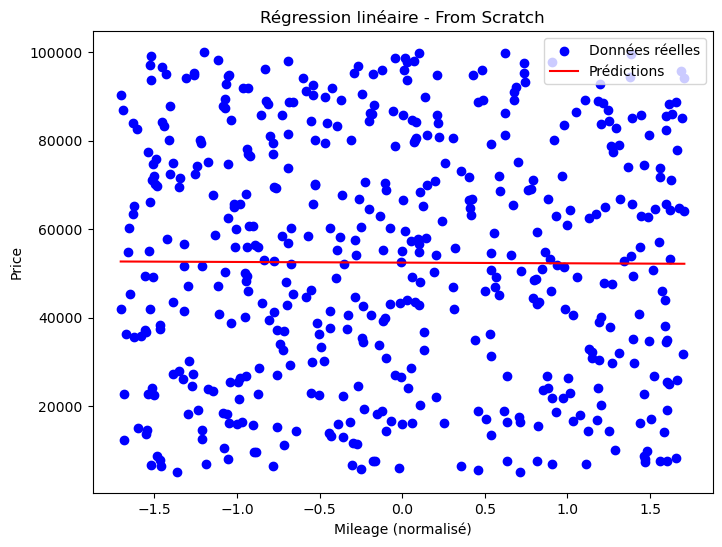

In [29]:
# 9. Prédictions (from scratch)

y_pred = X_test.dot(beta_final)
# On calcule les prédictions du modèle sur les données de test
# X_test : données d'entrée de test 
# beta_final : coefficients calculés par la descente de gradient
# Le résultat y_pred contient les prix prédits pour chaque voiture du test


# Trier pour un beau tracé
sorted_indices = X_test[:,1].argsort()    # On récupère les indices qui trient les valeurs de la variable "Mileage", Pourquoi ? Pour tracer la ligne de régression de manière ordonnée
X_sorted = X_test[sorted_indices]    # On réorganise X_test selon l’ordre des indices triés
y_pred_sorted = y_pred[sorted_indices]    # On réorganise les prédictions correspondantes pour suivre le même ordre


# 10. Visualisation (from scratch)

plt.figure(figsize=(8,6))
plt.scatter(X_test[:,1], y_test, color="blue", label="Données réelles")
# Affiche les points réels en bleu

plt.plot(X_sorted[:,1], y_pred_sorted, color="red", label="Prédictions")
# Trace la ligne de régression (prédictions) en rouge

plt.xlabel("Mileage (normalisé)")
plt.ylabel("Price")
plt.title("Régression linéaire - From Scratch")
plt.legend()
plt.show()
# Affiche la figure finale montrant les points réels et la prédiction du modèle

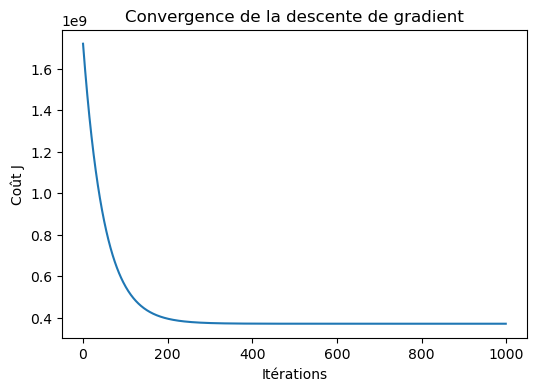

In [30]:
# 11. Visualisation de la convergence de la descente de gradient

# Ce graphique montre l'évolution du coût (erreur) au fil des itérations
# et permet de vérifier si le modèle converge correctement
plt.figure(figsize=(6,4))
plt.plot(cost_history)
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.title("Convergence de la descente de gradient")
plt.show()
# on conclut que La descente de gradient fonctionne correctement
# Plateau après 400–500 itérations → convergence atteinte, les coefficients beta sont optimaux.
# Courbe lisse et monotone → alpha bien choisi, descente stable.

In [31]:
# 12. Modèle Sklearn 

scaler = StandardScaler()    
#crée un objet StandardScaler de scikit-learn, StandardScaler() : c’est une classe de scikit-learn qui sert à standardiser les variables
#Cela est utile pour que toutes les variables soient sur la même échelle

X_scaled = scaler.fit_transform(X_original)
#fit_transform(X_original) : fait deux choses :
#fit : calcule la moyenne et l’écart-type de chaque colonne de X_original.
#transform : applique la normalisation à chaque colonne
#X_scaled : le résultat est une version normalisée de X_original

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#train_test_split : fonction de scikit-learn pour diviser les données en jeu d’entraînement et jeu de test.
#X_train_s et y_train_s : données d’entraînement.
#X_test_s et y_test_s : données de test

model = LinearRegression()   #LinearRegression() : crée un objet modèle de régression linéaire.

# Entraînement
model.fit(X_train_s, y_train_s)   #fit : le modèle apprend les coefficients (beta0, beta1,..) à partir des données d’entraînement.

# Prédictions
y_pred_sklearn = model.predict(X_test_s)
#predict : utilise les coefficients appris pour estimer les valeurs de y pour les nouvelles données 
#y_pred_sklearn : tableau contenant les prédictions pour chaque échantillon du jeu de test.

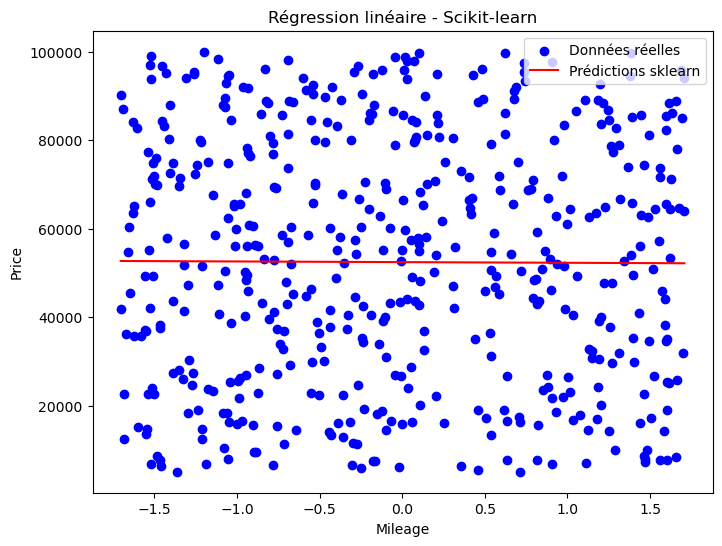

In [32]:
# 13. Visualisation sklearn

# Trier pour un beau tracé
sorted_indices = X_test_s[:,0].argsort()
X_sorted = X_test_s[sorted_indices]
y_pred_sorted = y_pred_sklearn[sorted_indices]

plt.figure(figsize=(8,6))
plt.scatter(X_test_s, y_test_s, color="blue", label="Données réelles")
plt.plot(X_sorted, y_pred_sorted, color="red", label="Prédictions sklearn")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Régression linéaire - Scikit-learn")
plt.legend()
plt.show()

In [33]:
# 14. Évaluation

print("----- From Scratch -----")
print("MSE :", mean_squared_error(y_test, y_pred))

print("\n----- Sklearn -----")
print("MSE :", mean_squared_error(y_test_s, y_pred_sklearn))

#mean_squared_error(y_true, y_pred) : calcule l’erreur quadratique moyenne (MSE)
#on observe que le MSE des deux sont très proches 
#et La différence très faible entre les deux confirme que l’algorithme apprend correctement les coefficients et prédit les valeurs de manière fiable.

----- From Scratch -----
MSE : 758182906.3774275

----- Sklearn -----
MSE : 758178642.3189518


### * Régression linéaire multiple : 

In [34]:
# 1. Préparation des données

features = ['Mileage', 'Engine Size', 'Year']   #Sélection des variables indépendantes (Mileage, Engine Size, Year) pour prédire le prix

X_original = data[features].values 
# Extraction des variables indépendantes X sous forme de matrice (plusieurs colonnes)
# Chaque ligne représente une voiture et chaque colonne une caractéristique

y = data['Price'].values.reshape(-1,1)   #On récupère la variable dépendante cible "Price" et transforme le vecteur en colonne (matrice)

# Normalisation 
X = (X_original - X_original.mean(axis=0)) / X_original.std(axis=0)
# On normalise X pour mettre toutes les variables sur la même échelle et améliorer la convergence de la descente de gradient

# Ajout du biais 
m = len(y)
X_b = np.hstack([np.ones((m,1)), X])
# Afin de simplifier les calculs matriciels, on ajoute une colonne de 1 à la matrice X
#Cela permet d’intégrer le biais (beta0) dans le vecteur des paramètres beta, et d’écrire le modèle sous forme matricielle : ŷ = Xβ

In [35]:
# 2. Train / Test 

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)
#On divise les données en deux parties :
# - Une partie "train" pour entraîner le modèle
# - Une partie "test" pour évaluer ses performances
# Le but est de vérifier si le modèle peut bien prédire sur de nouvelles données qu’il n’a jamais vues

In [36]:
# 3. Initialisation

n = X_b.shape[1] 
# n représente le nombre de variables (colonnes de X_b), y compris le biais
# Cela correspond au nombre de coefficients beta à apprendre


beta = np.random.randn(n,1)
# Initialisation aléatoire du vecteur beta (coefficients du modèle)
# Chaque coefficient est initialisé avec une valeur aléatoire pour commencer la descente de gradient
# La taille (n,1) correspond au nombre de variables dans le modèle

# 4. Fonctions

def compute_cost(X, y, beta):
    m = len(y)
    return (1/(2*m)) * np.sum((X.dot(beta) - y)**2)

def gradient_descent(X, y, beta, alpha=0.01, iterations=1000):
    m = len(y)
    cost_history = []   #une liste pour stocker l’évolution de l’erreur (coût) à chaque itération

    # Boucle pour effectuer la descente de gradient et améliorer progressivement beta
    for i in range(iterations):
        gradient = (1/m) * X.T.dot(X.dot(beta) - y)
        beta = beta - alpha * gradient
        cost_history.append(compute_cost(X, y, beta))

    return beta, cost_history

# 5. Entraînement

beta_final, cost_history = gradient_descent(X_train, y_train, beta)
# Appel de la fonction de descente de gradient pour entraîner le modèle
# sur les données d’apprentissage et obtenir les coefficients optimaux (beta_final)
# ainsi que l’évolution du coût (cost_history)

In [40]:
# 6. Prédictions

y_pred = X_test.dot(beta_final)
# On calcule les prédictions du modèle sur les données de test
# Le résultat y_pred contient les prix prédits pour chaque voiture du test

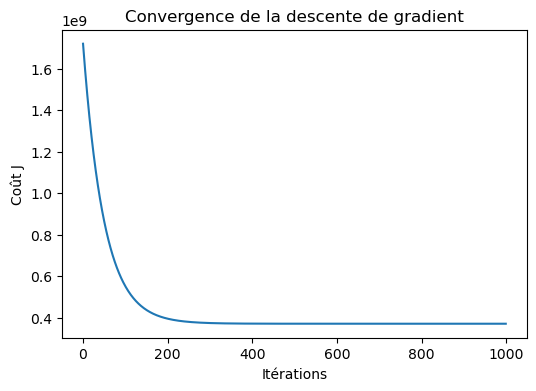

In [38]:
# 7. Visualisation de la convergence de la descente de gradient

plt.figure(figsize=(6,4))
plt.plot(cost_history)
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.title("Convergence de la descente de gradient")
plt.show()
# Ce graphique montre l'évolution du coût (erreur) au fil des itérations
# et permet de vérifier si le modèle converge correctement

In [41]:
# 8. Sklearn

scaler = StandardScaler()  # Création d’un objet StandardScaler pour normaliser les variables X
X_scaled = scaler.fit_transform(X_original)  
# fit : calcule la moyenne et l’écart-type de chaque variable
# transform : applique la normalisation sur X_original
# Résultat : X_scaled contient des variables sur la même échelle

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#train_test_split : fonction de scikit-learn pour diviser les données en jeu d’entraînement et jeu de test.
#X_train_s et y_train_s : données d’entraînement.
#X_test_s et y_test_s : données de test

model = LinearRegression()  #Création d’un modèle de régression linéaire avec sklearn
model.fit(X_train_s, y_train_s)   #fit : le modèle apprend les coefficients (beta0, beta1,..) à partir des données d’entraînement.


y_pred_sklearn = model.predict(X_test_s)
# Prédiction des valeurs de y à partir des données de test
# y_pred_sklearn contient les valeurs prédites par le modèle

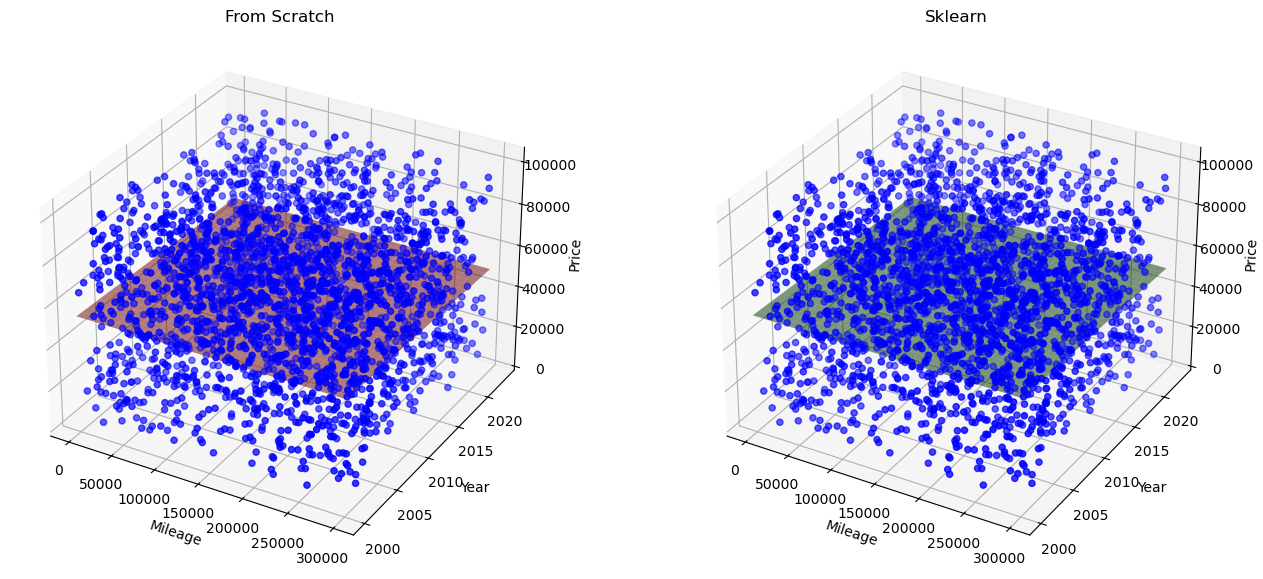

In [45]:
# 9. Sélection des variables pour le plot 3D

X_plot = data[['Mileage', 'Year']].values  # Variables indépendantes choisies pour les axes X et Y
y_plot = data['Price'].values              # Variable dépendante


# Normalisation pour from scratch
X_plot_norm = (X_plot - X_plot.mean(axis=0)) / X_plot.std(axis=0)
m_plot = len(y_plot)
X_plot_b = np.hstack([np.ones((m_plot,1)), X_plot_norm, np.zeros((m_plot,1))]) 
# on ajoute une colonne de biais et une colonne vide pour Engine Size 
# beta_final doit contenir les coefficients complets (biais, Mileage, Engine Size, Year)


# 10. Création de la grille pour la surface prédite

Mileage_range = np.linspace(X_plot[:,0].min(), X_plot[:,0].max(), 30)  #np.linspace(min, max, 30) : crée 30 valeurs régulièrement espacées entre le minimum et le maximum
Year_range = np.linspace(X_plot[:,1].min(), X_plot[:,1].max(), 30)
Mileage_grid, Year_grid = np.meshgrid(Mileage_range, Year_range)   #np.meshgrid : crée une grille 2D de tous les couples (Mileage, Year) pour tracer une surface continue


# Pour from scratch : normaliser la grille comme le training set
Mileage_grid_norm = (Mileage_grid - X_plot[:,0].mean()) / X_plot[:,0].std()
Year_grid_norm = (Year_grid - X_plot[:,1].mean()) / X_plot[:,1].std()

# Construire la matrice X pour prédiction (from scratch)
X_grid_b = np.c_[np.ones(Mileage_grid_norm.ravel().shape),   #ravel() transforme la grille 2D en un vecteur 1D pour chaque variable
                 Mileage_grid_norm.ravel(),                  #np.c_[] : combine les colonnes pour créer la matrice X complète pour la prédiction
                 np.zeros(Mileage_grid_norm.ravel().shape),  # Engine Size mis à 0 pour simplifier 
                 Year_grid_norm.ravel()]


#On calcule la prédiction sur toute la grille en multipliant X par beta_final
y_grid_pred_from_scratch = X_grid_b.dot(beta_final)  # prédiction from scratch
y_grid_pred_from_scratch = y_grid_pred_from_scratch.reshape(Mileage_grid.shape)


# 11. Préparation pour sklearn

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[['Mileage', 'Engine Size', 'Year']])
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y_plot, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train_s, y_train_s)

# Normalisation de la grille pour sklearn
grid_scaled = scaler.transform(np.c_[Mileage_grid.ravel(), np.zeros(Mileage_grid.ravel().shape), Year_grid.ravel()])
y_grid_pred_sklearn = model.predict(grid_scaled).reshape(Mileage_grid.shape)


# 12. Visualisation 3D

fig = plt.figure(figsize=(16,7))  #Création d’une figure matplotlib de taille large pour afficher les deux surfaces côte à côte

# From scratch
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_plot[:,0], X_plot[:,1], y_plot, color='blue', label='Données réelles')
ax1.plot_surface(Mileage_grid, Year_grid, y_grid_pred_from_scratch, color='red', alpha=0.5, label='Surface prédite')
ax1.set_title("From Scratch")
ax1.set_xlabel("Mileage")
ax1.set_ylabel("Year")
ax1.set_zlabel("Price")

# Sklearn
#Même principe pour sklearn.
#Surface verte = prédiction sklearn, points bleus = données réelles
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_plot[:,0], X_plot[:,1], y_plot, color='blue', label='Données réelles')   #affiche les points réels
ax2.plot_surface(Mileage_grid, Year_grid, y_grid_pred_sklearn, color='green', alpha=0.5, label='Surface prédite')  #affiche la surface prédite par le modèle from scratch
ax2.set_title("Sklearn")
ax2.set_xlabel("Mileage")
ax2.set_ylabel("Year")
ax2.set_zlabel("Price")

plt.show()   #Affiche le graphique final avec deux sous-plots 3D

In [20]:
# 13. Évaluation

print("----- From Scratch (Multiple) -----")
print("MSE :", mean_squared_error(y_test, y_pred))
print("\n----- Sklearn (Multiple) -----")
print("MSE :", mean_squared_error(y_test_s, y_pred_sklearn))

#mean_squared_error(y_true, y_pred) : calcule l’erreur quadratique moyenne (MSE)
#on observe que le MSE des deux sont très proches 
#et La différence très faible entre les deux confirme que l’algorithme apprend correctement les coefficients et prédit les valeurs de manière fiable.

----- From Scratch (Multiple) -----
MSE : 757754325.7280518

----- Sklearn (Multiple) -----
MSE : 757749532.1955932


## * Régression polynomiale :

In [21]:
# 1. Préparation des données

X_original = data['Mileage'].values.reshape(-1,1)   # Extraction de la variable indépendante (Mileage)
y = data['Price'].values.reshape(-1,1)   # Extraction de la variable dépendante (Price)

# Création des features polynomiales (degré 2)
X_poly = np.hstack([X_original, X_original**2])

# X_original**2 : on ajoute le carré de Mileage
# np.hstack : combine les colonnes pour obtenir [Mileage, Mileage^2]
# Cela permet de transformer une relation non linéaire en un modèle linéaire avec plusieurs variables

# Normalisation
X = (X_poly - X_poly.mean(axis=0)) / X_poly.std(axis=0)
# On normalise X pour mettre toutes les variables sur la même échelle et améliorer la convergence de la descente de gradient


# Ajout du biais
m = len(y)
X_b = np.hstack([np.ones((m,1)), X])
# Afin de simplifier les calculs matriciels, on ajoute une colonne de 1 à la matrice X
#Cela permet d’intégrer le biais (beta0) dans le vecteur des paramètres beta, et d’écrire le modèle sous forme matricielle : ŷ = Xβ

In [22]:
# 2. Train / Test spli

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)
#On divise les données en deux parties :
# - Une partie "train" pour entraîner le modèle
# - Une partie "test" pour évaluer ses performances
# Le but est de vérifier si le modèle peut bien prédire sur de nouvelles données qu’il n’a jamais vues

In [23]:
# 3. Initialisation

n = X_b.shape[1]
# n représente le nombre de variables (colonnes de X_b), y compris le biais
# Cela correspond au nombre de coefficients beta à apprendre
beta = np.random.randn(n,1)
# Initialisation aléatoire du vecteur beta (coefficients du modèle)
# Chaque coefficient est initialisé avec une valeur aléatoire pour commencer la descente de gradient
# La taille (n,1) correspond au nombre de variables dans le modèle

# 4. Fonctions

def compute_cost(X, y, beta):
    m = len(y)
    return (1/(2*m)) * np.sum((X.dot(beta) - y)**2)

def gradient_descent(X, y, beta, alpha=0.01, iterations=1000):
    m = len(y)
    cost_history = []   #une liste pour stocker l’évolution de l’erreur (coût) à chaque itération

    # Boucle pour effectuer la descente de gradient et améliorer progressivement beta
    for i in range(iterations):
        gradient = (1/m) * X.T.dot(X.dot(beta) - y)
        beta = beta - alpha * gradient
        cost_history.append(compute_cost(X, y, beta))

    return beta, cost_history


# 5. Entraînement

beta_final, cost_history = gradient_descent(X_train, y_train, beta)
# Appel de la fonction de descente de gradient pour entraîner le modèle
# sur les données d’apprentissage et obtenir les coefficients optimaux (beta_final)
# ainsi que l’évolution du coût (cost_history)

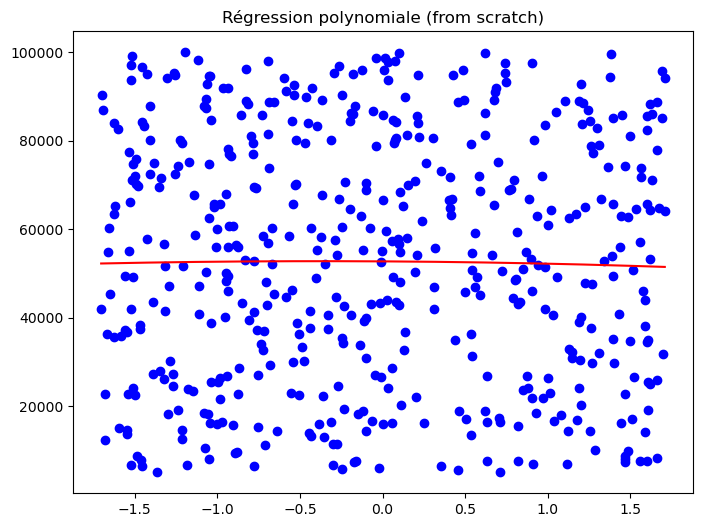

In [24]:
# 6. Prédictions

y_pred = X_test.dot(beta_final)
# On calcule les prédictions du modèle sur les données de test
# Le résultat y_pred contient les prix prédits pour chaque voiture du test


# 7. Visualisation (courbe)

# Trier pour un beau tracé
sorted_indices = X_test[:,1].argsort()
X_sorted = X_test[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.figure(figsize=(8,6))
plt.scatter(X_test[:,1], y_test, color="blue")
plt.plot(X_sorted[:,1], y_pred_sorted, color="red")
plt.title("Régression polynomiale (from scratch)")
plt.show()

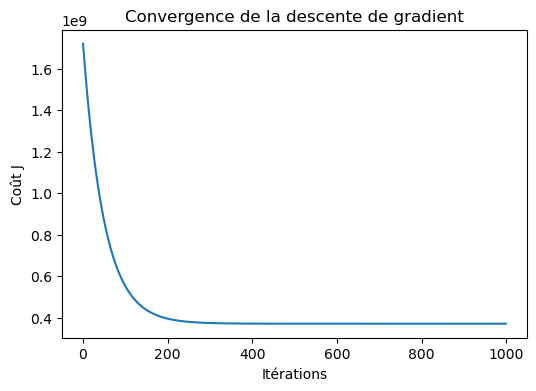

In [25]:
# 8. Visualisation de la convergence de la descente de gradient

plt.figure(figsize=(6,4))
plt.plot(cost_history)
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.title("Convergence de la descente de gradient")
plt.show()
# Ce graphique montre l'évolution du coût (erreur) au fil des itérations
# et permet de vérifier si le modèle converge correctement

In [26]:
# 9. Sklearn

poly = PolynomialFeatures(degree=2)
# Création d’un objet PolynomialFeatures
# degree=2 signifie qu’on ajoute des termes jusqu’au carré (x²)

X_poly_s = poly.fit_transform(X_original)
# Génération automatique des variables polynomiales :
# [1, X, X²] (le 1 correspond au biais)
# Permet de modéliser une relation non linéaire

scaler = StandardScaler()   # Création d’un objet pour normaliser les données
X_scaled = scaler.fit_transform(X_poly_s)
# Normalisation des variables polynomiales
# Important car X² peut avoir des valeurs beaucoup plus grandes que X

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)  
# Division des données en ensemble d’entraînement et de test

model = LinearRegression()
# Création du modèle de régression linéaire
# Même si c’est polynomiale, on utilise LinearRegression car le modèle est linéaire en beta

# Entraînement
model.fit(X_train_s, y_train_s)
# Entraînement du modèle sur les données d’apprentissage
# Le modèle apprend les coefficients optimaux

# Prédictions
y_pred_sklearn = model.predict(X_test_s)
# Prédiction des valeurs de y sur les données de test
# Permet d’évaluer les performances du modèle
# y_pred_sklearn contient les valeurs prédites par le modèle

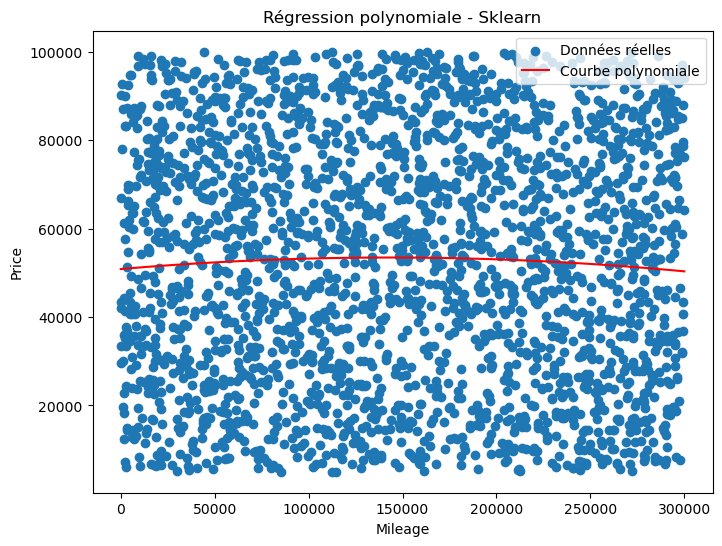

In [27]:
# 10. Visualisation polynomiale (sklearn)

# Trier pour un beau tracé
sorted_indices = X_original[:,0].argsort()   #On trie les valeurs de Mileage pour tracer une courbe lisse (sinon la ligne sera désordonnée)
X_sorted = X_original[sorted_indices]   #On réorganise les données selon cet ordre

# Transformer et normaliser les données triées
X_poly_sorted = poly.transform(X_sorted)
X_scaled_sorted = scaler.transform(X_poly_sorted)
#On applique les mêmes transformations que pendant l’entraînement : polynomiale (X → X, X²) et normalisation

# Prédictions
y_pred_sorted = model.predict(X_scaled_sorted)  #Le modèle prédit les valeurs de y (prix) pour les données triées

# Graphique
plt.figure(figsize=(8,6))
plt.scatter(X_original, y, label="Données réelles")
plt.plot(X_sorted, y_pred_sorted, color="red", label="Courbe polynomiale")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Régression polynomiale - Sklearn")
plt.legend()
plt.show()

In [42]:
# 11. Évaluation

print("----- From Scratch (Plynomial) -----")
print("MSE :", mean_squared_error(y_test, y_pred))
print("\n----- Sklearn (Plynomial) -----")
print("MSE :", mean_squared_error(y_test_s, y_pred_sklearn))

#mean_squared_error(y_true, y_pred) : calcule l’erreur quadratique moyenne (MSE)
#on observe que le MSE des deux sont très proches 
#et La différence très faible entre les deux confirme que l’algorithme apprend correctement les coefficients et prédit les valeurs de manière fiable.

----- From Scratch (Plynomial) -----
MSE : 757754325.795375

----- Sklearn (Plynomial) -----
MSE : 757749532.1955932
